# Two-Stage Supply Chain: Convergence Experiments

## Topic 2.1: Convergence behavior under different agent configurations


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import ExperimentConfig
from model import TwoStageSupplyChainModel
from centralsolver import compute_benchmark
from metrics import compute_run_metrics
from experiment_runner import run_experiment_grid, create_treatment_grid
from plotting import generate_all_plots

In [2]:
# Create config
cfg = ExperimentConfig(
    lam=20.0, rounds=365, warmup=50,
    agent_retailer="greedy", agent_supplier="greedy",
)

# Compute benchmark (system-optimal base-stocks)
s1_opt, s2_opt, ctot_opt = compute_benchmark(cfg)
print(f"System optimal: s1*={s1_opt}, s2*={s2_opt}, c*={ctot_opt:.2f}€")
print(f"Note: All metrics exclude the first {cfg.warmup} warmup rounds.")

System optimal: s1*=47, s2*=45, c*=24.10€
Note: All metrics exclude the first 50 warmup rounds.


In [3]:
# Run single simulation with fixed seed
model = TwoStageSupplyChainModel(config=cfg, seed=42)
model.run(cfg.rounds)

# Get data
df = model.datacollector.get_model_vars_dataframe()
df.head(10)

,Total Cost,Cost Retailer,Cost Supplier,S1,S2
0,120.0,60.0,60.0,1,15
1,197.5,95.0,102.5,47,47
2,221.5,102.5,119.0,0,27
3,175.5,75.0,100.5,5,32
4,16.0,2.0,14.0,35,41
5,17.5,4.0,13.5,26,37
6,118.0,50.0,68.0,55,51
7,47.5,20.0,27.5,27,9
8,89.0,42.5,46.5,48,5
9,143.5,70.0,73.5,22,0


In [4]:
# Compute metrics (warmup-aware)
metrics = compute_run_metrics(model, ctot_opt, cfg.rounds, cfg.warmup)
print(f"S1 converged: {metrics['s1_converged']} (final={metrics['s1_final']}, mode={metrics['s1_mode']})")
print(f"S2 converged: {metrics['s2_converged']} (final={metrics['s2_final']}, mode={metrics['s2_mode']})")
print(f"Train total regret (post-warmup): {metrics['train_total_regret']:.2f}€")
print(f"Train mean cost (post-warmup): {metrics['train_mean_cost']:.2f}€")

S1 converged: False (final=34, mode=34)
S2 converged: True (final=53, mode=53)
Train total regret (post-warmup): 15676.26€
Train mean cost (post-warmup): 73.86€


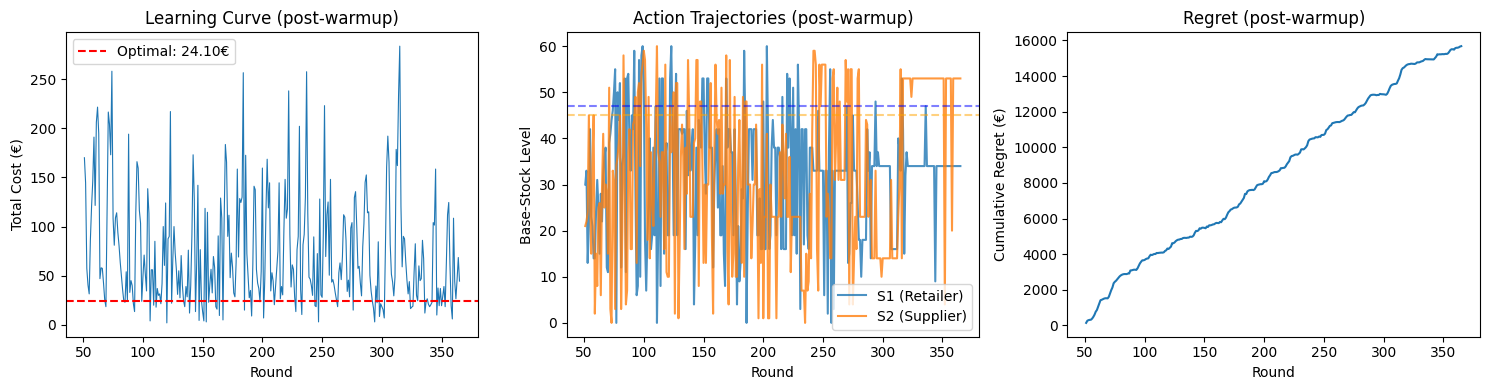

In [5]:
# Quick visualization (post-warmup data)
warmup = cfg.warmup
post_warmup_costs = df["Total Cost"].values[warmup:]
post_warmup_s1 = df["S1"].values[warmup:]
post_warmup_s2 = df["S2"].values[warmup:]
rounds = np.arange(warmup + 1, cfg.rounds + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Learning curve
axes[0].plot(rounds, post_warmup_costs, lw=0.8)
axes[0].axhline(ctot_opt, color="red", ls="--", label=f"Optimal: {ctot_opt:.2f}€")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Total Cost (€)")
axes[0].set_title("Learning Curve (post-warmup)")
axes[0].legend()

# Actions
axes[1].plot(rounds, post_warmup_s1, label="S1 (Retailer)", alpha=0.8)
axes[1].plot(rounds, post_warmup_s2, label="S2 (Supplier)", alpha=0.8)
axes[1].axhline(s1_opt, color="blue", ls="--", alpha=0.5)
axes[1].axhline(s2_opt, color="orange", ls="--", alpha=0.5)
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Base-Stock Level")
axes[1].set_title("Action Trajectories (post-warmup)")
axes[1].legend()

# Cumulative regret
cumreg = np.cumsum(post_warmup_costs - ctot_opt)
axes[2].plot(rounds, cumreg)
axes[2].set_xlabel("Round")
axes[2].set_ylabel("Cumulative Regret (€)")
axes[2].set_title("Regret (post-warmup)")

plt.tight_layout()
plt.show()

## Quick Experiment: 4 treatments × 10 seeds

In [6]:
# Run small experiment (4 treatments × 10 seeds)
treatments = create_treatment_grid()  # default: 4 agent pairs, (0,60,1) grid

results = run_experiment_grid(
    treatments=treatments,
    base_config=ExperimentConfig(rounds=200, warmup=30),
    n_seeds=10,
    output_dir="results_demo",
)

Running 4 treatments × 10 seeds
Base config: rounds=200, warmup=30, λ=20.0

[1/4]
  Treatment: greedy_greedy_s0-60-1
    Benchmark: s1*=47, s2*=45, c*=24.10

[2/4]
  Treatment: ucb_ucb_s0-60-1
    Benchmark: s1*=47, s2*=45, c*=24.10

[3/4]
  Treatment: greedy_ucb_s0-60-1
    Benchmark: s1*=47, s2*=45, c*=24.10

[4/4]
  Treatment: ucb_greedy_s0-60-1
    Benchmark: s1*=47, s2*=45, c*=24.10

Total time: 0.1s

Results saved to results_demo/
  summary.csv: 4 treatment summaries
  runs.csv: 40 individual runs


In [7]:
# Summary table (post-warmup metrics)
summary = results["summary_df"][
    ["treatment", "train_mean_cost_mean", "train_total_regret_mean", 
     "s1_convergence_rate", "s2_convergence_rate", "both_convergence_rate"]
]
summary

,treatment,train_mean_cost_mean,train_total_regret_mean,s1_convergence_rate,s2_convergence_rate,both_convergence_rate
0,greedy_greedy_s0-60-1,76.695588,8941.93,0.0,0.0,0.0
1,ucb_ucb_s0-60-1,65.666765,7067.03,0.7,0.6,0.6
2,greedy_ucb_s0-60-1,76.119118,8843.93,0.1,0.7,0.1
3,ucb_greedy_s0-60-1,80.867353,9651.13,0.0,0.0,0.0


In [8]:
# Generate all plots
generate_all_plots(results, "results_demo")

Generating plots...
Plots saved to results_demo/figures/


## Full Experiment (CLI)

```bash
# Run default experiment (50 seeds, 365 rounds, 50 warmup)
python run_experiments.py

# Quick test (5 seeds, 100 rounds)
python run_experiments.py --n_seeds 5 --rounds 100

# Full experiment with custom warmup
python run_experiments.py --n_seeds 100 --warmup 100
```

Results are saved to `results/` directory. All metrics exclude the first warmup rounds.